In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Częstotliwość logów ---
def czestotliwosc_data_csv(path='data.csv'):
    df = pd.read_csv(path)
    t = pd.to_datetime(df['timestamp'], format='%H:%M:%S.%f', errors='coerce')
    t = t.dropna()
    dt = t.diff().dt.total_seconds().dropna()
    dt = dt[dt > 0]  # tylko dodatnie (bez cofnięć zegara)
    n = len(df)
    czas_s = (t.max() - t.min()).total_seconds() if len(t) > 1 else 0
    mean_interval_s = float(dt.mean()) if len(dt) else 0
    freq_hz = 1 / mean_interval_s if mean_interval_s > 0 else 0
    print(f"--- {path} ---")
    print(f"  Liczba wpisów: {n}")
    print(f"  Średni odstęp między logami: {mean_interval_s*1000:.2f} ms")
    print(f"  Częstotliwość logowania: {freq_hz:.2f} Hz")
    if czas_s > 0:
        print(f"  Czas span (pierwszy–ostatni): {czas_s:.2f} s")
    print()

def czestotliwosc_log_csv(path='10_1.9.49.log.csv'):
    df = pd.read_csv(path, sep=';')
    if 'TIMESTAMP' not in df.columns:
        print(f"--- {path} --- brak kolumny TIMESTAMP")
        return
    ts = pd.to_numeric(df['TIMESTAMP'], errors='coerce').dropna()
    dt = ts.diff().dropna()
    dt = dt[dt > 0]
    n = len(df)
    mean_interval = float(dt.mean()) if len(dt) else 0
    # wartości typu 9547109, różnice ~200 → zakładamy ms
    mean_interval_s = mean_interval / 1000
    freq_hz = 1 / mean_interval_s if mean_interval_s > 0 else 0
    print(f"--- {path} ---")
    print(f"  Liczba wpisów: {n}")
    print(f"  Średni odstęp między logami: {mean_interval:.1f} ms")
    print(f"  Częstotliwość logowania: {freq_hz:.2f} Hz")
    print()


--- data.csv ---
  Liczba wpisów: 54217
  Średni odstęp między logami: 119.99 ms
  Częstotliwość logowania: 8.33 Hz
  Czas span (pierwszy–ostatni): 6505.52 s

--- 10_1.9.49.log.csv ---
  Liczba wpisów: 8088
  Średni odstęp między logami: 1.4 ms
  Częstotliwość logowania: 692.31 Hz



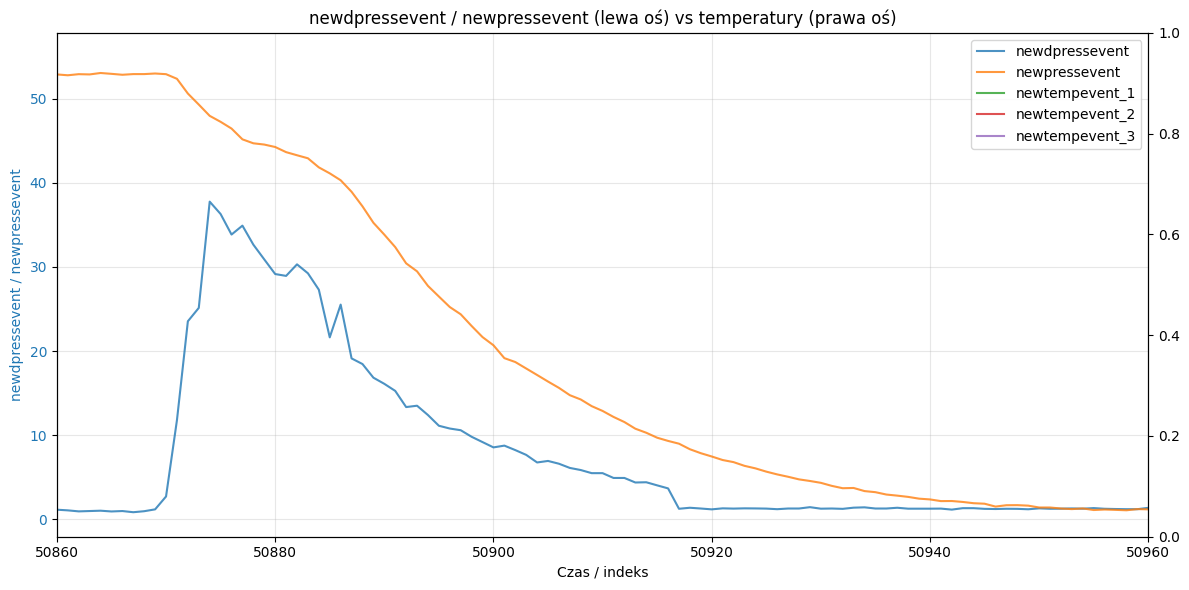

In [9]:

czestotliwosc_data_csv('data.csv')
czestotliwosc_log_csv('10_1.9.49.log.csv')

# Wczytaj dane
df = pd.read_csv('data.csv')

# Konwersja timestamp na indeks czasowy (opcjonalnie - dla osi X)
df['timestamp'] = pd.to_datetime(df['timestamp'], format='%H:%M:%S.%f', errors='coerce')
# Jeśli dużo punktów, można próbkować co N-ty wiersz dla czytelności
# df = df.iloc[::10]  # co 10. wiersz

fig, ax1 = plt.subplots(figsize=(12, 6))

# Lewa oś - newdpressevent i newpressevent
ax1.set_xlabel('Czas / indeks')
ax1.set_ylabel('newdpressevent / newpressevent', color='#1f77b4')
line1, = ax1.plot(df.index, df['newdpressevent'], color='#1f77b4', alpha=0.8, label='newdpressevent')
line2, = ax1.plot(df.index, df['newpressevent'], color='#ff7f0e', alpha=0.8, label='newpressevent')
ax1.tick_params(axis='y', labelcolor='#1f77b4')
ax1.grid(True, alpha=0.3)

# Prawa oś - temperatury
ax2 = ax1.twinx()
# ax2.set_ylabel('Temperatura (°C?)', color='#2ca02c')
# line3, = ax2.plot(df.index, df['newtempevent_1'], color='#2ca02c', alpha=0.8, label='newtempevent_1')
# line4, = ax2.plot(df.index, df['newtempevent_2'], color='#d62728', alpha=0.8, label='newtempevent_2')
# line5, = ax2.plot(df.index, df['newtempevent_3'], color='#9467bd', alpha=0.8, label='newtempevent_3')
# ax2.tick_params(axis='y', labelcolor='#2ca02c')

# Legenda - łączymy linie z obu osi
lines = [line1, line2, line3, line4, line5]
ax1.legend(lines, [l.get_label() for l in lines], loc='upper right')

plt.title('newdpressevent / newpressevent (lewa oś) vs temperatury (prawa oś)')
fig.tight_layout()
plt.xlim(50860, 50960)
plt.savefig('wykres.png', dpi=150, bbox_inches='tight')
plt.show()


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("dane_wykres_artur.csv")
df

,Index,Time,Timestamp,Count,Ecuid,Apid,Ctid,SessionId,Type,Subtype,Mode,#Args,Payload
0,0,2026/02/22 13:37:11.687332,8987.2746,1,EC--,ENVA,APP-,0,log,info,verbose,1,Receive new Tank Pressure: 53.27 Bar
1,1,2026/02/22 13:37:11.687373,8987.2818,1,EC--,ENVA,APP-,0,log,info,verbose,1,Receive new Tank D Pressure: 0.96 Bar
2,2,2026/02/22 13:37:11.687379,8987.2891,1,EC--,ENVA,APP-,0,log,info,verbose,1,Receive new Tank Pressure: 53.30 Bar
3,3,2026/02/22 13:37:11.696784,8987.2965,1,EC--,ENVA,APP-,0,log,info,verbose,1,Receive new Tank D Pressure: 1.00 Bar
4,4,2026/02/22 13:38:50.731064,8987.3041,1,EC--,ENVA,APP-,0,log,info,verbose,1,Receive new Tank Pressure: 53.16 Bar
...,...,...,...,...,...,...,...,...,...,...,...,...,...
264212,264342,2026/02/22 14:12:44.689016,11119.7356,1,EC--,ENVA,APP-,0,log,info,verbose,1,Receive new Tank D Pressure: 1.12 Bar
264213,264343,2026/02/22 14:12:44.695884,11119.7432,1,EC--,ENVA,APP-,0,log,info,verbose,1,Receive new Tank Pressure: 1.10 Bar
264214,264344,2026/02/22 14:12:44.703456,11119.7502,1,EC--,ENVA,APP-,0,log,info,verbose,1,Receive new Tank D Pressure: 1.14 Bar
264215,264345,2026/02/22 14:12:44.711066,11119.7578,1,EC--,ENVA,APP-,0,log,info,verbose,1,Receive new Tank Pressure: 1.10 Bar


In [4]:
# Ulepszony Regex: obsłuży spacje, dwukropki i format naukowy (np. 1.2e-3)
regex_pattern = r'(\d+\.?\d*(?:e[-+]?\d+)?)'

# Wyciąganie wartości
df['newpressevent'] = df['Payload'].str.extract(r'Receive new Tank Pressure:\D+([\d.]+)').astype(float)
df['newdpressevent'] = df['Payload'].str.extract(r'Receive new Tank D Pressure:\D+([\d.]+)').astype(float)

df

,Index,Time,Timestamp,Count,Ecuid,Apid,Ctid,SessionId,Type,Subtype,Mode,#Args,Payload,newpressevent,newdpressevent
0,0,2026/02/22 13:37:11.687332,8987.2746,1,EC--,ENVA,APP-,0,log,info,verbose,1,Receive new Tank Pressure: 53.27 Bar,53.27,NaN
1,1,2026/02/22 13:37:11.687373,8987.2818,1,EC--,ENVA,APP-,0,log,info,verbose,1,Receive new Tank D Pressure: 0.96 Bar,NaN,0.96
2,2,2026/02/22 13:37:11.687379,8987.2891,1,EC--,ENVA,APP-,0,log,info,verbose,1,Receive new Tank Pressure: 53.30 Bar,53.30,NaN
3,3,2026/02/22 13:37:11.696784,8987.2965,1,EC--,ENVA,APP-,0,log,info,verbose,1,Receive new Tank D Pressure: 1.00 Bar,NaN,1.00
4,4,2026/02/22 13:38:50.731064,8987.3041,1,EC--,ENVA,APP-,0,log,info,verbose,1,Receive new Tank Pressure: 53.16 Bar,53.16,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
264212,264342,2026/02/22 14:12:44.689016,11119.7356,1,EC--,ENVA,APP-,0,log,info,verbose,1,Receive new Tank D Pressure: 1.12 Bar,NaN,1.12
264213,264343,2026/02/22 14:12:44.695884,11119.7432,1,EC--,ENVA,APP-,0,log,info,verbose,1,Receive new Tank Pressure: 1.10 Bar,1.10,NaN
264214,264344,2026/02/22 14:12:44.703456,11119.7502,1,EC--,ENVA,APP-,0,log,info,verbose,1,Receive new Tank D Pressure: 1.14 Bar,NaN,1.14
264215,264345,2026/02/22 14:12:44.711066,11119.7578,1,EC--,ENVA,APP-,0,log,info,verbose,1,Receive new Tank Pressure: 1.10 Bar,1.10,NaN


In [5]:
# 1. Kopiujemy dane i zmieniamy nazwy kolumn
df2 = df[['Timestamp', 'newpressevent', 'newdpressevent']].copy()
df2.columns = ['Timestamp', 'New Pressure', 'D Pressure']


# Wypełnia luki ostatnią znaną wartością (Forward Fill)
df2[['New Pressure', 'D Pressure']] = df2[['New Pressure', 'D Pressure']].ffill()

# Opcjonalnie usuń wiersze, które nadal mają NaN na początku (jeśli pierwszy rekord był pusty)
# df2.dropna(inplace=True)

df2['Timestamp'] -= df2['Timestamp'][0]

df2.head()


,Timestamp,New Pressure,D Pressure
0,0.0000,53.27,NaN
1,0.0072,53.27,0.96
2,0.0145,53.30,0.96
3,0.0219,53.30,1.00
4,0.0295,53.16,1.00


In [6]:
df2['New Pressure'] = df2['New Pressure'].rolling(15).mean()

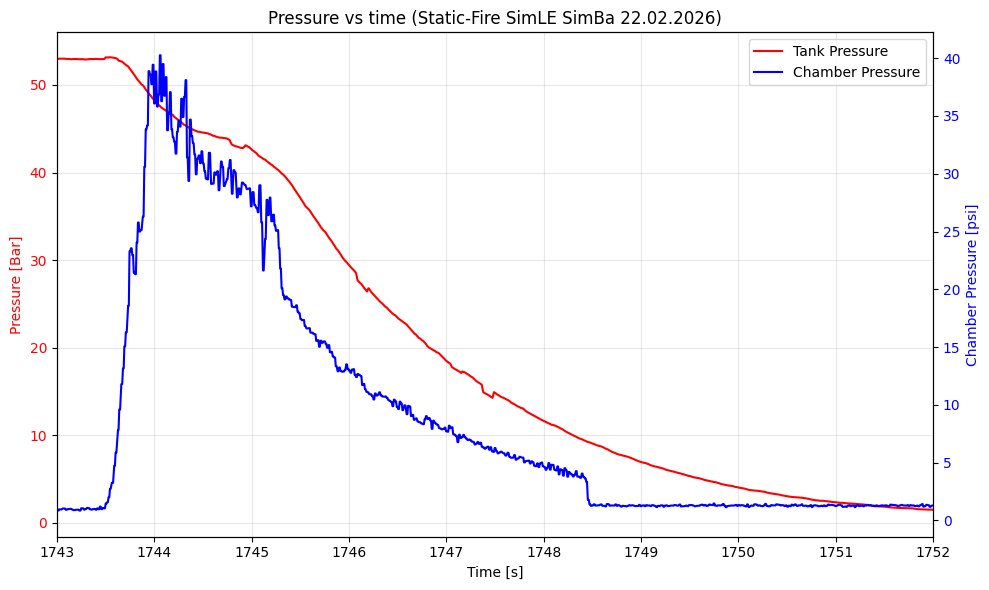

In [7]:
# 1. Inicjalizacja figury i pierwszej osi (lewej)
fig, ax1 = plt.subplots(figsize=(10, 6))

# Wykres dla Tank Pressure (Oś Lewa)
line1 = ax1.plot(df2["Timestamp"], df2["New Pressure"], color='r', label="Tank Pressure")
ax1.set_xlabel('Time [s]')
ax1.set_ylabel('Pressure [Bar]', color='r')
ax1.tick_params(axis='y', labelcolor='r')

# 2. Tworzenie drugiej osi (prawej) współdzielącej oś X
ax2 = ax1.twinx()

# Wykres dla Chamber Pressure (Oś Prawa)
line2 = ax2.plot(df2['Timestamp'], df2["D Pressure"], color='b', label="Chamber Pressure")
ax2.set_ylabel('Chamber Pressure [psi]', color='b')
ax2.tick_params(axis='y', labelcolor='b')

# 3. Połączona legenda (bo mamy dwa różne obiekty osi)
lns = line1 + line2
labs = [l.get_label() for l in lns]
ax1.legend(lns, labs, loc='upper right')

plt.title('Pressure vs time (Static-Fire SimLE SimBa 22.02.2026)')
ax1.grid(True, alpha=0.3) # Grid zazwyczaj lepiej wygląda tylko dla głównej osi

plt.xlim(1743, 1752)

plt.tight_layout()
plt.show()

Prośba, żeby stworzyć wykres, który: po lewej ciśnienie w bar, po prawej ciśnienie w psi i na dole sekundy

Opis osi w stylu:
Pressure [bar]
Pressure [psi]
Time [s]

I tytuł wykresu:
Pressure vs time

I jak można to legenda, ale to najwyżej się napisze 
Wtedy wstawię jako dodatek do Progress update jeszcze to, bo ładnie wygląda 

In [65]:
def oblicz_czestotliwosc(df, kolumna_timestamp='Timestamp'):
    """
    Oblicza częstotliwość próbkowania w Hz na podstawie kolumny z czasem (w sekundach).
    """
    # 1. Obliczamy różnice między kolejnymi wierszami (diff)
    deltas = df[kolumna_timestamp].diff().dropna()
    
    # 2. Wyciągamy średni odstęp czasu
    avg_delta = deltas.mean()
    
    # 3. Częstotliwość to odwrotność czasu (1/s = Hz)
    czestotliwosc = 1 / avg_delta
    
    return czestotliwosc

# Wynik
hz = oblicz_czestotliwosc(df2)
print(f"Częstotliwość próbkowania: {hz:.2f} Hz")

Częstotliwość próbkowania: 123.90 Hz


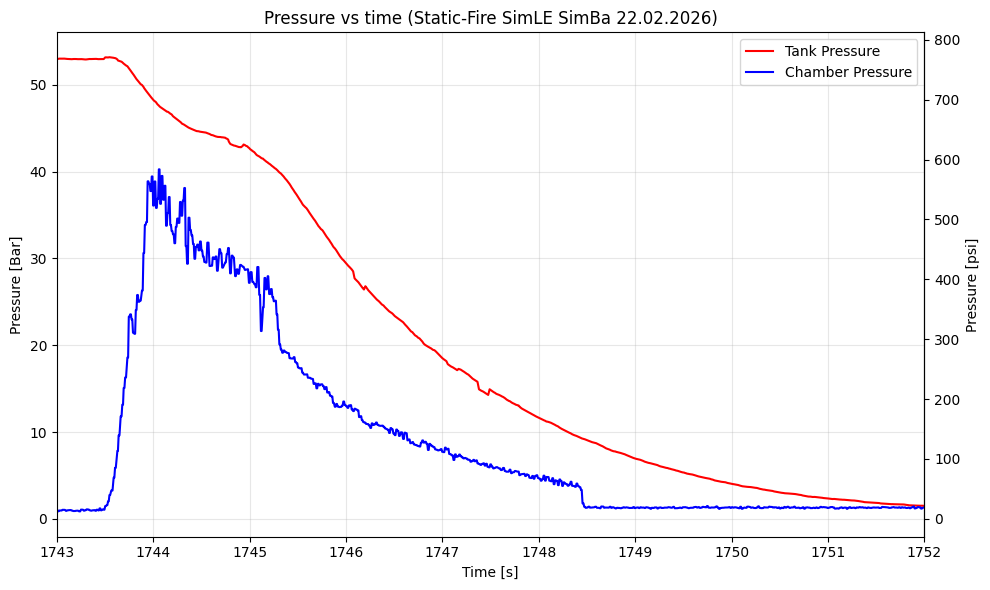

In [11]:
import matplotlib.pyplot as plt

# Współczynnik konwersji: 1 Bar = 14.50377 PSI
def bar_to_psi(x):
    return x * 14.50377

def psi_to_bar(x):
    return x / 14.50377

# 1. Inicjalizacja figury i głównej osi (lewej - BAR)
fig, ax1 = plt.subplots(figsize=(10, 6))

# Rysujemy OBA wykresy na ax1 (lewa oś)
line1 = ax1.plot(df2["Timestamp"], df2["New Pressure"], color='r', label="Tank Pressure")
line2 = ax1.plot(df2['Timestamp'], df2["D Pressure"], color='b', label="Chamber Pressure")

ax1.set_xlabel('Time [s]')
ax1.set_ylabel('Pressure [Bar]')
ax1.grid(True, alpha=0.3)

# 2. Tworzenie wtórnej osi Y (prawej) za pomocą secondary_yaxis
# 'right' oznacza położenie, a 'functions' definiuje przeliczenie w obie strony
secax = ax1.secondary_yaxis('right', functions=(bar_to_psi, psi_to_bar))
secax.set_ylabel('Pressure [psi]')

# 3. Legenda i ustawienia widoku
lns = line1 + line2
labs = [l.get_label() for l in lns]
ax1.legend(lns, labs, loc='upper right')

plt.title('Pressure vs time (Static-Fire SimLE SimBa 22.02.2026)')
plt.xlim(1743, 1752)

plt.tight_layout()
plt.show()